In [1]:
# Import module constrained_likelihood_surrogates
#
import sys
sys.path.append("../src/")
from constrained_likelihood_surrogates import *

In [2]:
# default_col_list = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

line_style_list = ['-', '--', '-.', ':', '-', '--', '-.', ':', '-', '--', '-.', ':']
col_list = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple', 'tab:brown', 'tab:pink', 'tab:gray', 'tab:olive', 'tab:cyan']
marker_list = ['s', 'd', 'o', '|', '_', '+', 'x', '1', '2', '3', '4', '*', '8', 'p']

load_folder_name = '../data/brain/'

process_list = ['powerlaw', 'lognorm', 'expon', 'truncnorm', 'uniform']
num_processes = len(process_list)
model_list = process_list
num_models = len(model_list)
method_list = ['constrained', 'typical']
num_methods = len(method_list)

In [3]:
# Load degree and strength list each from a text file:

save_str = 'celegans_herm_degrees.txt'
with open(load_folder_name + save_str) as file:
    lines = file.readlines()
    deg_list = [int(line.strip()) for line in lines]
          
save_str = 'celegans_herm_strengths.txt'
with open(load_folder_name + save_str) as file:
    lines = file.readlines()
    strength_list = [int(line.strip()) for line in lines]
deg_string = ''

Degree, lower_cutoff = 1.5, N_list = [4, 7, 12, 20, 33, 57, 97, 165, 280]
Strength, lower_cutoff = 4.5, N_list = [4, 7, 12, 20, 33, 57, 96, 163, 277]


C:\Users\murdo\AppData\Local\Temp\ipykernel_25292\3250740424.py:201: RuntimeWarning: invalid value encountered in sqrt
  bin_centres_left = np.sqrt(bins_left[:-1]*bins_left[1:])  # Midpoints for marker placement
C:\Users\murdo\AppData\Local\Temp\ipykernel_25292\3250740424.py:201: RuntimeWarning: invalid value encountered in sqrt
  bin_centres_left = np.sqrt(bins_left[:-1]*bins_left[1:])  # Midpoints for marker placement


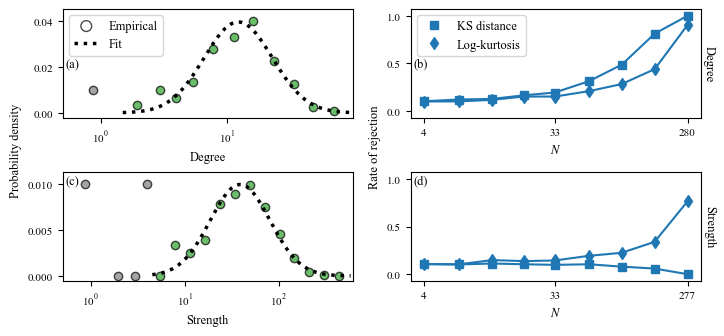

In [5]:
#
# # Load results: hypothesis testing
#
test_type = 'rejection'

load_folder_name = './results/hyp-test/brain/'

# lower_cutoff_hat_list = [0.5, 0.5]#Minimum positive observed value - 0.5
lower_cutoff_hat_list = [1.5, 4.5]#Minimum value which avoids obvious deviations
# lower_cutoff_hat_list = [5.5, 11.5]#Value which minimises KS-distance for maximum likelihood lognormal fit

num_surr = 99
num_tests = 10**3
num_free_stats, num_depe_stats = 20, 7
# model_list = ['powerlaw', 'lognorm', 'expon', 'truncnorm', 'uniform']
# model_list = ['lognorm', 'truncnorm']
model_list = ['lognorm']
num_models = len(model_list)
method_list = ['constrained', 'typical']
num_methods = len(method_list)

measure_list = ['Degree', 'Strength']
num_measures = len(measure_list)
measure_seq_list = [deg_list, strength_list]

for i_measure in range(num_measures):
    measure = measure_list[i_measure]
    measure_seq = measure_seq_list[i_measure]
    
    lower_cutoff = lower_cutoff_hat_list[i_measure]
    val_seq_full = [val for val in measure_seq if (val >= lower_cutoff)]
    N_max = len(val_seq_full)#Number of data not less than lower cutoff
    log_N_list = np.linspace(np.log(4), np.log(N_max), 9)
    N_list = np.round(np.exp(log_N_list))
    N_list = [int(N) for N in N_list]
    num_N = len(N_list)
    N_tick_list = [N_list[ind] for ind in [0, 4, 8]]
    
    print(f'{measure}, lower_cutoff = {lower_cutoff}, N_list = {N_list}')

    free_quantile_mat = np.zeros((num_N, num_methods, num_models, num_tests, num_free_stats))
    depe_quantile_mat = np.zeros((num_N, num_methods, num_models, num_tests, num_depe_stats))

    for i_N in range(num_N):
        N = N_list[i_N]
        num_trans = N*(int(np.ceil(np.log2(N*1024))))
        save_str_0 = 'quant_free-depe' + '_' + test_type + '_xmin-' + str(lower_cutoff) + '_N-' + str(N) + '_ntra-' + str(num_trans) + '_nsur-' + str(num_surr) + '_ntes-' + str(num_tests) + '_ntyp-' + str(num_methods) + '_nmod-' + str(num_models) + '_nfs-' + str(num_free_stats) + '_nds-' + str(num_depe_stats)
        process_str = '_celegans_' + measure
        save_str = save_str_0 + process_str
        with open(load_folder_name + save_str + '.json', 'r') as read_file:
            save_dict = json.load(read_file)

        free_quantile_list_list = np.array(save_dict['free_quantile_list_list'])#Array of nans: num_methods x num_models x num_tests x num_free_stats
        free_quantile_mat[i_N, :, :, :, :] = free_quantile_list_list# num_N x num_methods x num_models x num_tests x num_free_stats

        depe_quantile_list_list = np.array(save_dict['depe_quantile_list_list'])#Array of nans: num_methods x num_models x num_tests x num_depe_stats
        depe_quantile_mat[i_N, :, :, :, :] = depe_quantile_list_list# num_N x num_methods x num_models x num_tests x num_depe_stats

        N = save_dict['N']
        num_trans = save_dict['num_trans']
        save_str = save_dict['save_str']
        total_time = save_dict['total_time']

    # test_type = save_dict['test_type']
    # lower_cutoff = save_dict['lower_cutoff']
    # num_surr = save_dict['num_surr']
    # num_tests = save_dict['num_tests']
    # num_methods = save_dict['num_methods']
    # process_str = save_dict['process_str']
    # model_list = save_dict['model_list']
    free_stat_name_list = save_dict['free_stat_name_list']
    depe_stat_name_list = save_dict['depe_stat_name_list']
    # measure_seq = save_dict['measure_seq']
    # val_seq_full = save_dict['val_seq_full']

    nominal_size = 0.10

    kL, kU = binom.interval(0.9, num_tests, nominal_size)
    pL, pU = kL/num_tests, kU/num_tests
    pL = nominal_size - np.sqrt(nominal_size*(1 - nominal_size)/num_tests)
    pU = nominal_size + np.sqrt(nominal_size*(1 - nominal_size)/num_tests)
    
    if (i_measure == 0):# degree
        degree_free_quantile_mat = free_quantile_mat
        degree_depe_quantile_mat = depe_quantile_mat
    elif (i_measure == 1):# strength
        strength_free_quantile_mat = free_quantile_mat
        strength_depe_quantile_mat = depe_quantile_mat

stat_type_list = ['depe', 'free']#KS, kurtosis of log of measurements
side_list = ['right-tailed', 'two-sided']#KS, kurtosis of log of measurements
i_stat_list = [0, 15]#KS, kurtosis of log of measurements

i_model = 0#lognorm
model = model_list[i_model]

num_stats_to_consider = len(i_stat_list)


#
## Plotting:
#
fig, ax_array = plt.subplots(2, 2, figsize=(7, 3))

base_font_size = 9; set_main_fonts(base_font_size=base_font_size)#Set font size and style
label_font_size = 1.0*base_font_size;

for i_measure in range(num_measures):
    #
    # # Hypothesis testing (right panel):
    #
    ax = ax_array[i_measure][1]
    measure = measure_list[i_measure]
    lower_cutoff = lower_cutoff_hat_list[i_measure]
    val_seq_full = [val for val in measure_seq if (val >= lower_cutoff)]
    N_max = len(val_seq_full)#Number of data not less than lower cutoff
    log_N_list = np.linspace(np.log(4), np.log(N_max), 9)
    N_list = np.round(np.exp(log_N_list))
    N_list = [int(N) for N in N_list]
    num_N = len(N_list)
    N_tick_list = [N_list[ind] for ind in [0, 4, 8]]
    
    if (i_measure == 0):# degree
        free_quantile_mat = degree_free_quantile_mat 
        depe_quantile_mat = degree_depe_quantile_mat
        corner = 'center left'#Location of panel label
    elif (i_measure == 1):# strength
        free_quantile_mat = strength_free_quantile_mat
        depe_quantile_mat = strength_depe_quantile_mat
        corner = 'upper left'#Location of panel label
    
    for i_stats_to_consider in range(num_stats_to_consider):
        stat_type = stat_type_list[i_stats_to_consider]
        i_stat = i_stat_list[i_stats_to_consider]
        side = side_list[i_stats_to_consider]
    
        if (stat_type == 'free'):
            stat_name_list = free_stat_name_list
            quantile_mat = free_quantile_mat
        elif (stat_type == 'depe'):
            stat_name_list = depe_stat_name_list
            quantile_mat = depe_quantile_mat
        stat_name = stat_name_list[i_stat]
        full_stat_name = beautify_stat_name(stat_name)

        if (side == 'left-tailed'):
            rej_mat = (quantile_mat < nominal_size)# num_N x num_methods x num_models x num_tests x num_stats
        elif (side == 'right-tailed'):
            rej_mat = (quantile_mat > (1 - nominal_size))# num_N x num_methods x num_models x num_tests x num_stats
        elif (side == 'two-sided'):
            rej_mat = ((quantile_mat > (1 - 0.5*nominal_size)) + (quantile_mat < 0.5*nominal_size))# num_N x num_methods x num_models x num_tests x num_stats

        rej_rate_mat = np.sum(rej_mat, axis=3)/num_tests# num_N x num_methodsx num_models x num_free_stats
        std_rej_rate_mat = np.std(rej_mat, axis=3, ddof=0)# num_N x num_methods x num_models x num_free_stats

        meth_to_consider_list = [0]#[constrained]
        # meth_to_consider_list = [0, 1]#[constrained, typical]
        for i_method in meth_to_consider_list:
            method = method_list[i_method]
            rej_rate_list = rej_rate_mat[:, i_method, i_model, i_stat]
            # err_list = np.sqrt(rej_rate_list*(1 - rej_rate_list)/num_tests)
            err_list = std_rej_rate_mat[:, i_method, i_model, i_stat]/np.sqrt(num_tests)
            ax.plot([], [], color=col_list[i_method], linestyle='None', marker=marker_list[i_stats_to_consider], label=full_stat_name)
            #ax.plot([], [], color=col_list[i_method], linestyle=line_style_list[i_method], marker=marker_list[i_stats_to_consider], label=full_stat_name)
            ax.errorbar(N_list, rej_rate_list, err_list, color=col_list[i_method], linestyle=line_style_list[i_method], marker=marker_list[i_stats_to_consider])

        ax.set_xscale('log')
        ax.xaxis.set_minor_locator(NullLocator())
        ax.xaxis.set_minor_formatter(NullFormatter())
        ax.set_xticks(N_tick_list)
        ax.set_xticklabels(N_tick_list)
        x_lim = [min(N_list)*(max(N_list)/min(N_list))**-0.05, max(N_list)*(max(N_list)/min(N_list))**+0.05]
        ax.set_xlim(x_lim)
        ax.set_ylim([-0.07, 1.07])
        ax.set_xlabel('$N$')

    panel_label = get_panel_label(ax, ax_array, order='row-major')
    add_panel_label(ax, panel_label, corner=corner, offset='auto')
    
    #
    # # Empirical pdf and fit (left panel):
    #
    ax = ax_array[i_measure][0]
    lower_cutoff_hat = lower_cutoff_hat_list[i_measure]
    if (i_measure == 0):
        val_seq, x_lim = deg_list, [10**-1, 10**4]
    elif (i_measure == 1):
        val_seq, x_lim = strength_list, [10**0, 10**5]
    
    # Calculate num_bin log-spaced bin at "half-integers"
    b = 3**(1/3)
    log_of_bins_right = np.arange(np.log(lower_cutoff_hat), np.log(np.max(val_seq)) + 0.5*np.log(b), np.log(b))
    log_of_bins_left = np.arange(np.log(0.5), np.log(lower_cutoff_hat) + 0.5*np.log(b), np.log(b))
    
    # Define log bins on left
    bins_left = np.exp(log_of_bins_left)
    bins_left = np.concatenate(([-0.5], bins_left)) #
    bins_left = np.round(bins_left - 0.5) + 0.5#Round bins_left to nearest half-integer
    bins_left = np.unique(bins_left)
    num_bins_left = len(bins_left) - 1
    bin_centres_left = np.sqrt(bins_left[:-1]*bins_left[1:])  # Midpoints for marker placement
    
    # Compute histogram counts and bin centres on left
    counts_left, _ = np.histogram(val_seq, bins=bins_left)  # counts
    density_left, _ = np.histogram(val_seq, bins=bins_left, density=True)  # density normalization
    
    # Define log bins on right
    bins_right = np.exp(log_of_bins_right)
    bins_right = np.round(bins_right - 0.5) + 0.5#Round bins_right to nearest half-integer
    bins_right = np.unique(bins_right)
    num_bins_right = len(bins_right) - 1
    bin_centres_right = np.sqrt(bins_right[:-1]*bins_right[1:])  # Midpoints for marker placement
    
    # Compute histogram counts and bin centres on right
    counts_right, _ = np.histogram(val_seq, bins=bins_right)  # counts
    density_right, _ = np.histogram(val_seq, bins=bins_right, density=True)  # density normalization
    
    N_left = sum(counts_left)
    N_right = sum(counts_right)
    N = N_left + N_right

    # Plot with circular markers
    ax.scatter([], [], s=60, color='None', edgecolor='k', alpha=0.7, marker='o', label='Empirical')
    ax.scatter(bin_centres_left, (N_left/N)*density_left, color='tab:gray', edgecolor='black', alpha=0.7, marker='o')#, label='empirical ($x < x_{\min}$)')
    ax.scatter(bin_centres_right, (N_right/N)*density_right, color='tab:green', edgecolor='black', alpha=0.7, marker='o')#, label='empirical ($x \geq x_{\min}$)')
    
    lower_cutoff_hat = lower_cutoff_hat
    val_seq_right = [val for val in val_seq if (val >= lower_cutoff_hat)]
    param_hat, lp_seq = fit_model(val_seq_right, model=model, lower_cutoff_hat=lower_cutoff_hat)

    if (model == 'powerlaw'):
        lambda_hat = param_hat[0]
        fit_pdf_fun = lambda seq : expon.pdf(np.log(seq), loc=np.log(lower_cutoff_hat), scale=1/lambda_hat)/seq
    elif (model == 'lognorm'):#Truncated lognormal distribution
        if (not np.isinf(param_hat[1])):#Could fit lognormal using maximum likelihood
            mu_hat, sigma_hat = param_hat[0], param_hat[1]
            fit_pdf_fun = lambda seq : truncnorm.pdf(np.log(seq), (np.log(lower_cutoff_hat) - mu_hat)/sigma_hat, (np.inf - mu_hat)/sigma_hat, loc=mu_hat, scale=sigma_hat)/seq
        else:#Could not fit lognormal using maximum likelihood: consider powerlaw instead
            lambda_hat = param_hat[0]
            fit_pdf_fun = lambda seq : expon.pdf(np.log(seq), loc=np.log(lower_cutoff_hat), scale=1/lambda_hat)/seq
    elif (model == 'expon'):#Exponential distribution
        lambda_hat = param_hat[0]
        fit_pdf_fun = lambda seq : expon.pdf(seq, loc=lower_cutoff_hat, scale=1/lambda_hat)
    elif (model == 'truncnorm'):#Truncated Gaussian distribution
        if (not np.isinf(param_hat[1])):#Could fit truncated normal using maximum likelihood
            mu_hat, sigma_hat = param_hat[0], param_hat[1]
            # mu_hat, sigma_hat = np.mean(val_seq_right), np.std(val_seq_right)
            fit_pdf_fun = lambda seq : truncnorm.pdf(seq, (lower_cutoff_hat - mu_hat)/sigma_hat, (np.inf - mu_hat)/sigma_hat, loc=mu_hat, scale=sigma_hat)
        else:#Could not fit truncated normal using maximum likelihood: consider exponential instead
            lambda_hat = param_hat[0]
            fit_pdf_fun = lambda seq : expon.pdf(seq, loc=lower_cutoff_hat, scale=1/lambda_hat)
    elif (model == 'uniform'):#Uniform distribution
        b_hat = param_hat[0]
        a = lower_cutoff_hat
        fit_pdf_fun = lambda seq : uniform.pdf(seq, loc=a, scale=(b_hat - a))
    else:
        raise Exception('model=' + str(model) + ' not recognised.')

    x = np.arange(lower_cutoff_hat, np.max(val_seq) + 0.8, 0.01)
    fit_pdf = fit_pdf_fun(x)

    ax.plot(x, N_right/N*fit_pdf, color='k', linestyle=':', label='Fit', linewidth=2.5)

    x_lim = list(ax.get_xlim())
    x_lim[0] = 0.5
    ax.set_xlim(x_lim)
    ax.set_xscale('log')  # Log scale for x-axis to match logbins
    ax.set_xlabel(measure)
    ax.set_ylim([-0.05*max(density_right), 1.05*max(density_right)])

    panel_label = get_panel_label(ax, ax_array, order='row-major')
    add_panel_label(ax, panel_label, corner=corner, offset='auto')
    
ax_array[0][0].legend(ncol=1, loc='upper left')
ax_array[0][1].legend(ncol=1, loc='upper left')

# fig.tight_layout(pad=0.5)
plt.subplots_adjust(wspace=0.20, hspace=0.5)

ax_array[1][0].set_ylabel('Probability density', y=1.2)
ax_array[1][1].set_ylabel('Rate of rejection', y=1.24)
    
bbox = fig.get_tightbbox(fig.canvas.get_renderer())
scale = fig.get_figwidth()/bbox.width
fig.set_size_inches(fig.get_size_inches()*scale, forward=True)

for i_measure in [0, 1]:
    measure = measure_list[i_measure]
    ax = ax_array[i_measure][1]
    x = ax.get_position().x1 + 0.01#For right label
    y = (ax.get_position().y0 + ax.get_position().y1)/2#For right label
    fig.text(x, y, measure, va='center', ha='center', rotation=270, fontsize=label_font_size)
    ax = ax_array[i_measure][0]
    ax.xaxis.set_minor_locator(NullLocator())

# label_subplots(ax_array, corner='center left', offset=(1, -2.5), order='row-major')

fig_name_str = 'pdf_hyp-testing_' + model + '_' + 'brain'
plt.savefig('figures\\' + fig_name_str + '.pdf', bbox_inches='tight')
plt.savefig('figures\\' + fig_name_str + '.png', bbox_inches='tight')

plt.show()